In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("global_ads_performance_dataset.csv")
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


### Dataset Overview

### Categorical (Dimensions)
- `date` → when campaign ran
- `platform` → e.g., Google, Facebook
- `campaign_type` → search, display, social
- `industry` → business category
- `country` → geo location
### Performance Metrics (Raw Inputs)
- `impressions` → how many times ad shown
- `clicks` → user interactions
- `ad_spend` → money spent
- `conversions` → desired actions (purchase, signup)
### Derived KPIs (VERY IMPORTANT)
#### These are already present—but we DO NOT trust blindly. We verify.
- `CTR` → Click Through Rate
- `CPC` → Cost Per Click
- `CPA` → Cost Per Acquisition
- `ROAS` → Return on Ad Spend
- `revenue` → money generated

In [3]:
df.shape

(1800, 14)

In [4]:
df.columns

Index(['date', 'platform', 'campaign_type', 'industry', 'country',
       'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA',
       'revenue', 'ROAS'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   object 
 1   platform       1800 non-null   object 
 2   campaign_type  1800 non-null   object 
 3   industry       1800 non-null   object 
 4   country        1800 non-null   object 
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 197.0+ KB


In [6]:
df.describe()

,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,102919.018889,3962.675556,0.038427,1.572756,6171.527272,181.562222,46.608961,30101.850450,6.450367
std,55740.900690,2941.858037,0.017082,0.800872,5776.996958,171.424239,41.185556,34560.032941,6.590986
min,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000
25%,54948.000000,1678.000000,0.025400,0.950000,1966.587500,59.000000,20.202500,7275.757500,2.170000
50%,103653.000000,3318.000000,0.035550,1.460000,4393.860000,130.000000,33.375000,18362.965000,4.295000
75%,150470.250000,5628.000000,0.049800,2.050000,8455.830000,252.250000,56.812500,38963.385000,8.212500
max,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000


### Handling null values

In [7]:
df.isnull().sum()

date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

In [8]:
null_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

null_df.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
date,0,0.0
platform,0,0.0
campaign_type,0,0.0
industry,0,0.0
country,0,0.0
impressions,0,0.0
clicks,0,0.0
CTR,0,0.0
CPC,0,0.0
ad_spend,0,0.0


### KPI Validation

In [9]:
# CTR = clicks / impressions
df["CTR_check"] = df["clicks"] / df["impressions"]

# CPC = ad_spend / clicks
df["CPC_check"] = df["ad_spend"] / df["clicks"]

# CPA = ad_spend / conversions
df["CPA_check"] = df["ad_spend"] / df["conversions"]

# ROAS = revenue / ad_spend
df["ROAS_check"] = df["revenue"] / df["ad_spend"]

In [10]:
df[["ROAS", "ROAS_check"]].head()

,ROAS,ROAS_check
0,1.80,1.804186
1,10.41,10.410851
2,2.06,2.059770
3,6.45,6.446742
4,0.39,0.388922


In [11]:
df[["CTR", "CTR_check"]].head()

,CTR,CTR_check
0,0.0353,0.035284
1,0.0385,0.038493
2,0.0649,0.064899
3,0.0707,0.070694
4,0.0489,0.048896


In [12]:
df[["CPC", "CPC_check"]].head()

,CPC,CPC_check
0,1.26,1.26
1,1.18,1.18
2,0.85,0.85
3,1.32,1.32
4,1.93,1.93


In [13]:
df[["CPA", "CPA_check"]].head()

,CPA,CPA_check
0,16.74,16.744528
1,14.99,14.986861
2,19.07,19.072472
3,26.47,26.466892
4,80.97,80.969813


### Checking the difference

In [14]:
df["CTR_diff"] = (df["CTR"] - df["CTR_check"]).abs()
df["CPC_diff"] = (df["CPC"] - df["CPC_check"]).abs()
df["CPA_diff"] = (df["CPA"] - df["CPA_check"]).abs()
df["ROAS_diff"] = (df["ROAS"] - df["ROAS_check"]).abs()

In [15]:
diff_df = pd.DataFrame({
    'Mean Difference': [
        df["CTR_diff"].mean(),
        df["CPC_diff"].mean(),
        df["CPA_diff"].mean(),
        df["ROAS_diff"].mean()
    ],
    'Max Difference': [
        df["CTR_diff"].max(),
        df["CPC_diff"].max(),
        df["CPA_diff"].max(),
        df["ROAS_diff"].max()
    ]
}, index=["CTR", "CPC", "CPA", "ROAS"])

diff_df

,Mean Difference,Max Difference
CTR,9.471889e-06,1.770784e-04
CPC,5.973617e-17,4.440892e-16
CPA,2.479205e-03,5.000000e-03
ROAS,2.492519e-03,4.994570e-03


In [16]:
diff_df.map(lambda x: f"{x:.10f}")

,Mean Difference,Max Difference
CTR,0.0000094719,0.0001770784
CPC,0.0000000000,0.0000000000
CPA,0.0024792047,0.0050000000
ROAS,0.0024925191,0.0049945703


### Coverting date column to date datatype

In [17]:
df["date"] = pd.to_datetime(df["date"])

### Handling duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

### Handling zero(0) values

In [20]:
zero_df = pd.DataFrame({
    'Zero Count': (df[['clicks', 'conversions', 'impressions', 'ad_spend']] == 0).sum(),
    'Percentage (%)': ((df[['clicks', 'conversions', 'impressions', 'ad_spend']] == 0).sum() / len(df)) * 100
})

zero_df

,Zero Count,Percentage (%)
clicks,0,0.0
conversions,0,0.0
impressions,0,0.0
ad_spend,0,0.0


### Feature Scaling

In [21]:
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["year"] = df["date"].dt.year

In [22]:
df["profit"] = df["revenue"] - df["ad_spend"]

## EDA
### Which platform gives best ROI?

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [24]:
platform_perf = df.groupby("platform").agg({
    "impressions": "sum",
    "clicks": "sum",
    "conversions": "sum",
    "ad_spend": "sum",
    "revenue": "sum",
    "ROAS": "mean",
    "CTR": "mean"
}).reset_index()

platform_perf

,platform,impressions,clicks,conversions,ad_spend,revenue,ROAS,CTR
0,Google Ads,73801150,2936149,131098,6349268.91,22033744.95,4.113028,0.039856
1,Meta Ads,64403494,1596736,73262,2106061.67,11926045.79,6.915730,0.024983
2,TikTok Ads,47049590,2599931,122452,2653418.51,20223540.07,9.538600,0.054963


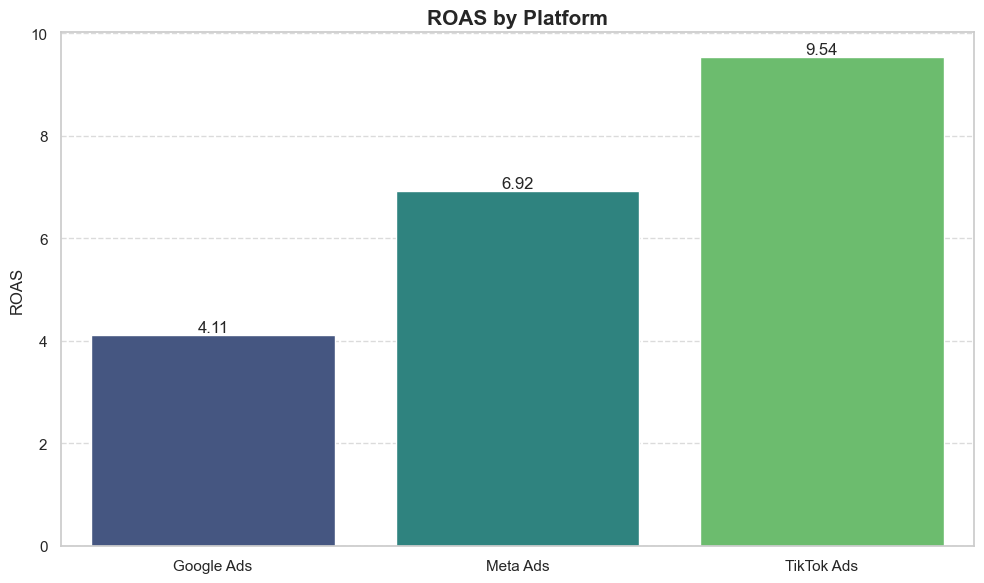

In [25]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=platform_perf, x="platform", y="ROAS", hue="platform",palette="viridis")
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
plt.title("ROAS by Platform", fontsize=15, fontweight='bold')
plt.xlabel("")
plt.ylabel("ROAS")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Insight:
**TikTok Ads leads with the highest average ROAS of 9.54, followed by Meta Ads at 6.92, while Google Ads lags significantly at 4.11. Despite Google Ads generating the highest absolute revenue (`$22M`), its massive spend of `$6.35M` makes it the least efficient platform. TikTok Ads delivers more than 2x the return per dollar spent compared to Google Ads — a strong signal to rebalance budget toward TikTok.**

### Campaign type performance

In [26]:
campaign_perf = df.groupby("campaign_type").agg({
    "impressions": "sum",
    "clicks": "sum",
    "conversions": "sum",
    "ad_spend": "sum",
    "revenue": "sum",
    "ROAS": "mean"
}).reset_index()

campaign_perf

,campaign_type,impressions,clicks,conversions,ad_spend,revenue,ROAS
0,Display,43487104,1638396,76869,2644735.12,12798903.17,6.448667
1,Search,47544475,1898227,90641,2868006.85,15218470.85,7.000273
2,Shopping,46474038,1785310,80074,2799548.64,12824695.60,5.977740
3,Video,47748617,1810883,79228,2796458.48,13341261.19,6.340000


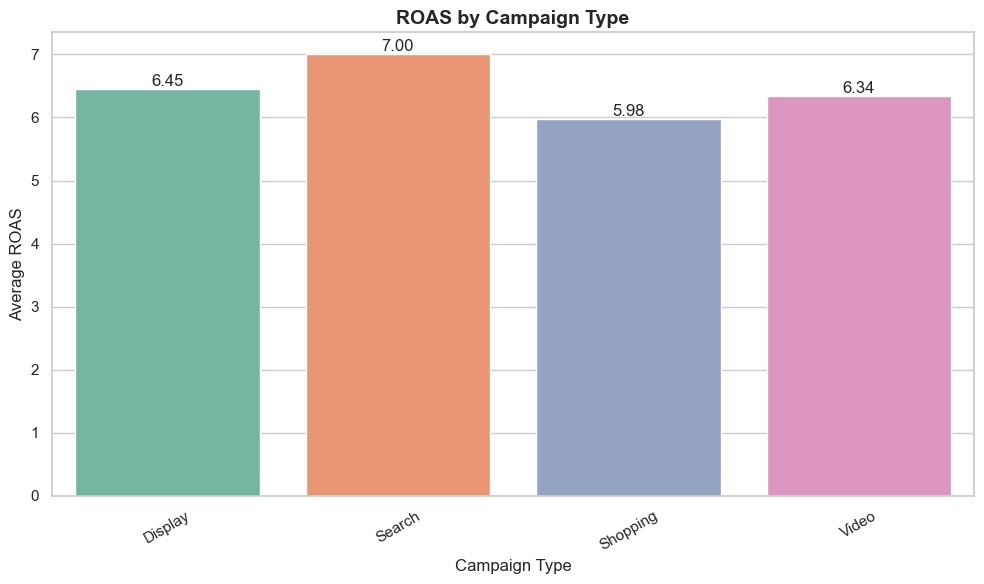

In [27]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=campaign_perf, x="campaign_type", y="ROAS",hue="campaign_type",palette="Set2")
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
plt.title("ROAS by Campaign Type", fontsize=14, fontweight='bold')
plt.xlabel("Campaign Type")
plt.ylabel("Average ROAS")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Insight:
**Search campaigns are the top performers with an average ROAS of 7.00, followed by Display (6.45), Video (6.34), and Shopping (5.98). The gap between Search and Shopping is ~1.02 ROAS points, indicating that intent-driven Search ads convert more efficiently. Search campaigns should be prioritized for budget scaling.**

### KPI Summary

In [28]:
kpi_summary = df[["impressions", "clicks", "conversions", "ad_spend", "revenue"]].sum()

kpi_summary

impressions    1.852542e+08
clicks         7.132816e+06
conversions    3.268120e+05
ad_spend       1.110875e+07
revenue        5.418333e+07
dtype: float64

In [29]:
kpi_summary.apply(lambda x: f"{x:,.2f}")

impressions    185,254,234.00
clicks           7,132,816.00
conversions        326,812.00
ad_spend        11,108,749.09
revenue         54,183,330.81
dtype: object

## Time based trend analysis

### Aggregate by date

In [33]:
daily_perf = df.groupby("date").agg({
    "impressions": "sum",
    "clicks": "sum",
    "conversions": "sum",
    "ad_spend": "sum",
    "revenue": "sum"
}).reset_index()

In [34]:
daily_perf.head()

,date,impressions,clicks,conversions,ad_spend,revenue
0,2024-01-01,124728,10066,295,16134.38,50301.88
1,2024-01-02,529701,16452,933,20193.39,148114.79
2,2024-01-03,439794,16323,537,26868.92,115945.04
3,2024-01-04,776104,17423,1116,29183.16,141881.21
4,2024-01-05,493694,13953,504,23209.18,90967.89


In [41]:
daily_perf["CTR"] = daily_perf["clicks"] / daily_perf["impressions"]
daily_perf["ROAS"] = daily_perf["revenue"] / daily_perf["ad_spend"]

### Revenue Trend Over Time

In [45]:
daily_perf.nlargest(5, "revenue")[["date", "revenue"]]

,date,revenue
178,2024-06-28,493584.79
94,2024-04-04,485916.39
343,2024-12-14,453315.30
107,2024-04-17,443464.85
103,2024-04-13,440955.68


In [47]:
daily_perf.nsmallest(5, "revenue")[["date", "revenue"]]

,date,revenue
90,2024-03-31,3173.67
232,2024-08-23,5739.99
188,2024-07-09,7592.89
162,2024-06-12,7976.29
279,2024-10-10,8973.49


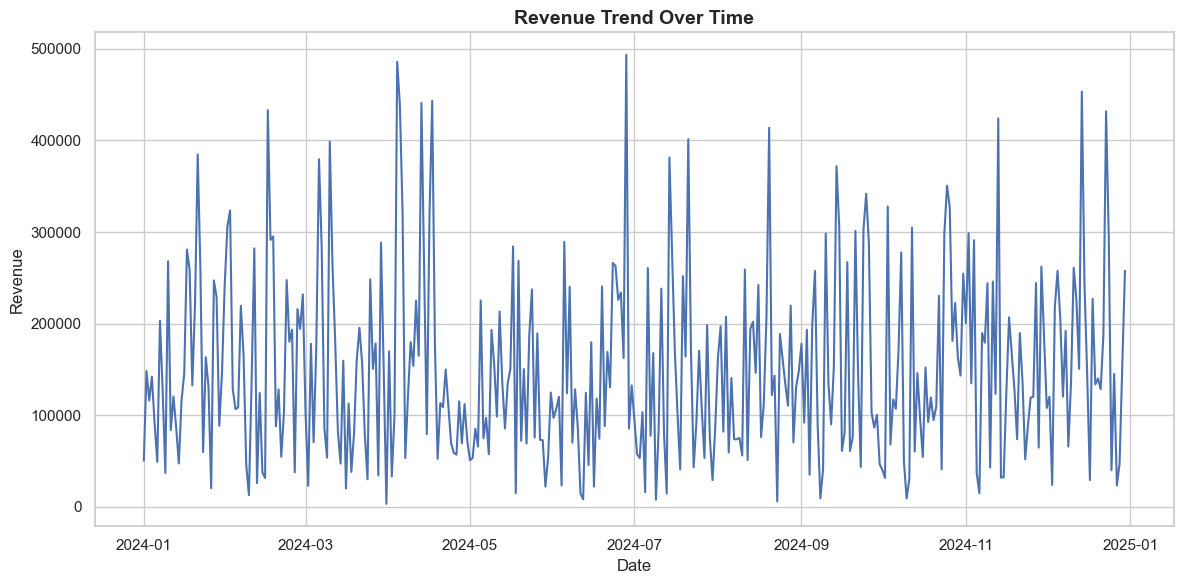

In [44]:
plt.figure(figsize=(12,6))

sns.lineplot(data=daily_perf, x="date", y="revenue")
plt.title("Revenue Trend Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Insight:
**Daily revenue fluctuates widely — from a peak of `$493,584` (June 28, 2024) down to a low of just `$3,174` (March 31, 2024), with an average daily revenue of `$150,509`. This ~155x gap between best and worst days suggests high campaign volatility, pointing to inconsistent scheduling, seasonal effects, or audience targeting issues on low-performing days**

### ROAS Trend Over Time

In [67]:
daily_perf.nlargest(5, "revenue")[["date", "revenue","ROAS"]]

,date,revenue,ROAS
178,2024-06-28,493584.79,5.996171
94,2024-04-04,485916.39,6.784677
343,2024-12-14,453315.30,5.312712
107,2024-04-17,443464.85,8.304240
103,2024-04-13,440955.68,5.571847


In [66]:
daily_perf.nsmallest(5, "revenue")[["date", "revenue","ROAS"]]

,date,revenue,ROAS
90,2024-03-31,3173.67,0.928642
232,2024-08-23,5739.99,1.098388
188,2024-07-09,7592.89,2.539751
162,2024-06-12,7976.29,0.993283
279,2024-10-10,8973.49,2.166228


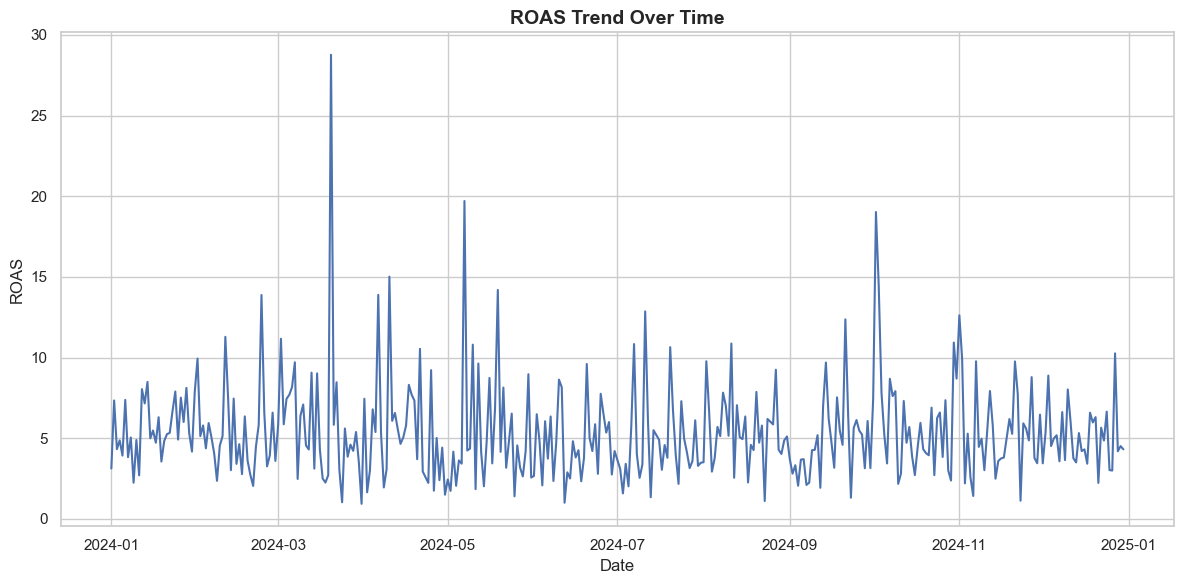

In [64]:
plt.figure(figsize=(12,6))

sns.lineplot(data=daily_perf, x="date", y="ROAS")

plt.title("ROAS Trend Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("ROAS")

plt.tight_layout()
plt.show()

### Insight:
**Daily ROAS ranged from a high of 28.77 (March 20, 2024) to a low of 0.93 (March 31, 2024), with an average of 5.37. Days where ROAS dropped below 1.0 (like March 31) mean the business lost money on ad spend that day. These dips require immediate attention to identify what drove cost spikes or conversion collapses.**

### Ad Spend vs Revenue Trend Over Time

In [46]:
daily_perf.nlargest(5, "revenue")[["date", "revenue","ad_spend"]]

,date,revenue,ad_spend
178,2024-06-28,493584.79,82316.66
94,2024-04-04,485916.39,71619.68
343,2024-12-14,453315.30,85326.53
107,2024-04-17,443464.85,53402.22
103,2024-04-13,440955.68,79139.95


In [48]:
daily_perf.nsmallest(5, "revenue")[["date", "revenue","ad_spend"]]

,date,revenue,ad_spend
90,2024-03-31,3173.67,3417.54
232,2024-08-23,5739.99,5225.83
188,2024-07-09,7592.89,2989.62
162,2024-06-12,7976.29,8030.23
279,2024-10-10,8973.49,4142.45


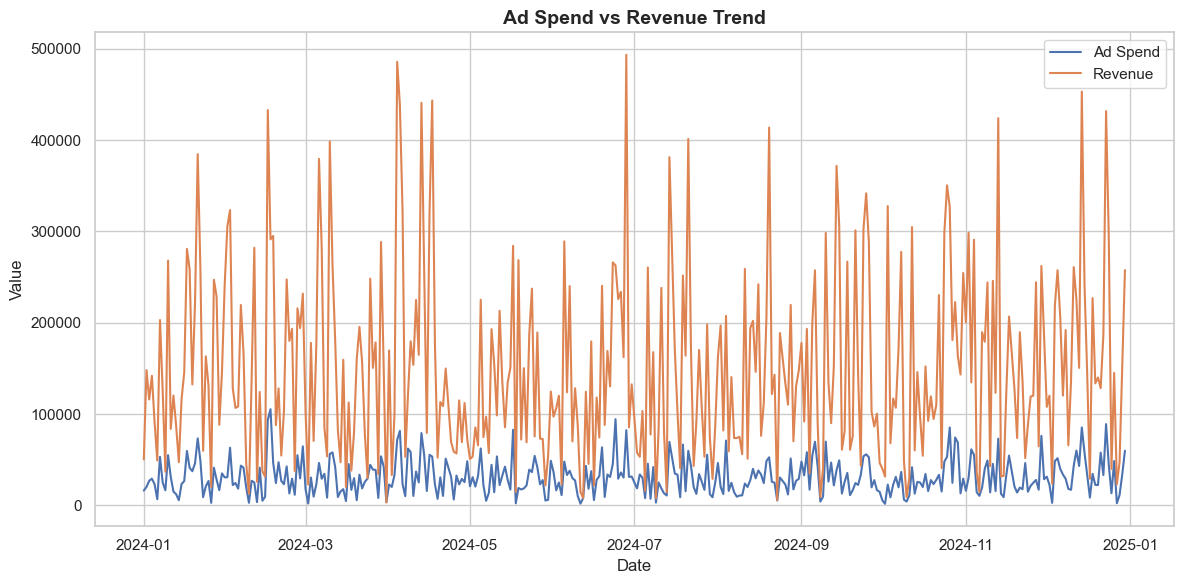

In [36]:
plt.figure(figsize=(12,6))

sns.lineplot(data=daily_perf, x="date", y="ad_spend", label="Ad Spend")
sns.lineplot(data=daily_perf, x="date", y="revenue", label="Revenue")

plt.title("Ad Spend vs Revenue Trend", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.show()

### Insight:
**Total ad spend across the period was `$11.1M`, generating `$54.2M` in revenue — an overall ROAS of 4.88. While revenue generally tracks spend, days where the two diverge (e.g., March 31 revenue at `$3,174` despite spend) reveal pockets of severely wasteful spending that drag down the overall portfolio efficiency**

### Best Performing Campaigns (by ROAS)

In [49]:
best_campaigns = df.groupby("campaign_type").agg({
    "revenue": "sum",
    "ad_spend": "sum"
}).reset_index()

best_campaigns["ROAS"] = best_campaigns["revenue"] / best_campaigns["ad_spend"]

best_campaigns.sort_values(by="ROAS", ascending=False)

,campaign_type,revenue,ad_spend,ROAS
1,Search,15218470.85,2868006.85,5.306288
0,Display,12798903.17,2644735.12,4.839389
3,Video,13341261.19,2796458.48,4.770770
2,Shopping,12824695.60,2799548.64,4.580987


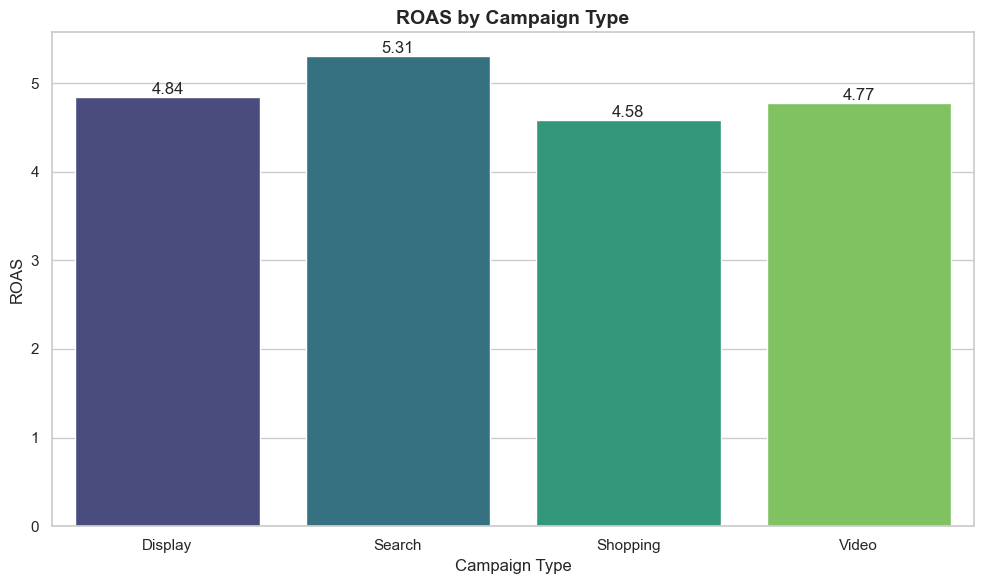

In [52]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=best_campaigns, x="campaign_type", y="ROAS", hue="campaign_type",palette="viridis")
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title("ROAS by Campaign Type", fontsize=14, fontweight='bold')
plt.xlabel("Campaign Type")
plt.ylabel("ROAS")

plt.tight_layout()
plt.show()

### Insights:
**Based on actual revenue-to-spend ratios, Search campaigns top the chart at 5.31 ROAS (`$15.2M` revenue / `$2.87M` spend), followed by Display at 4.84, Video at 4.77, and Shopping at 4.58. Search's `$0.73` ROAS advantage over Shopping at this scale translates to millions in incremental return — reallocating Shopping budgets to Search could significantly boost overall ROI.**

### Platform Profitability

In [53]:
platform_profit = df.groupby("platform").agg({
    "revenue": "sum",
    "ad_spend": "sum"
}).reset_index()

platform_profit["profit"] = platform_profit["revenue"] - platform_profit["ad_spend"]
platform_profit["ROAS"] = platform_profit["revenue"] / platform_profit["ad_spend"]

platform_profit.sort_values(by="profit", ascending=False)

,platform,revenue,ad_spend,profit,ROAS
2,TikTok Ads,20223540.07,2653418.51,17570121.56,7.621693
0,Google Ads,22033744.95,6349268.91,15684476.04,3.470281
1,Meta Ads,11926045.79,2106061.67,9819984.12,5.662724


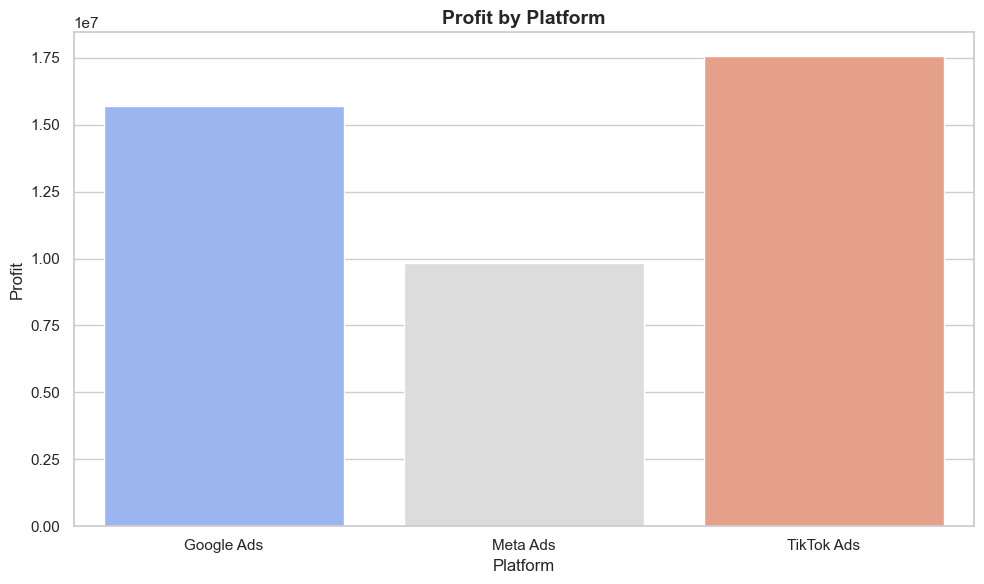

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(data=platform_profit, x="platform", y="profit", hue="platform", palette="coolwarm")

plt.title("Profit by Platform", fontsize=14, fontweight='bold')
plt.xlabel("Platform")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### Insights:
**TikTok Ads generated the highest absolute profit of `$17.57M` on just `$2.65M` in spend. Google Ads delivered `$15.68M` profit but required `$6.35M` in spend — more than double TikTok's investment. Meta Ads generated `$9.82M` profit on `$2.11M` spend. TikTok Ads is the most capital-efficient platform, generating `~$6.62` profit per dollar spent vs. Google's `~$2.47`.**

### Wasteful Spend (High Spend, Low Conversion)

In [56]:
wasteful = df.sort_values(by="ad_spend", ascending=False).head(10)

wasteful[["campaign_type", "platform", "ad_spend", "conversions", "CPA"]]

,campaign_type,platform,ad_spend,conversions,CPA
711,Video,Google Ads,38453.32,264,145.66
945,Search,Google Ads,38184.01,122,312.98
24,Display,Google Ads,32656.06,407,80.24
77,Video,Google Ads,32235.84,336,95.94
1070,Shopping,Google Ads,31106.27,609,51.08
624,Video,Google Ads,31017.48,321,96.63
1788,Shopping,Google Ads,29503.44,294,100.35
1354,Shopping,Google Ads,29383.65,517,56.83
1525,Search,Google Ads,29043.28,335,86.70
1322,Search,Google Ads,28803.36,215,133.97


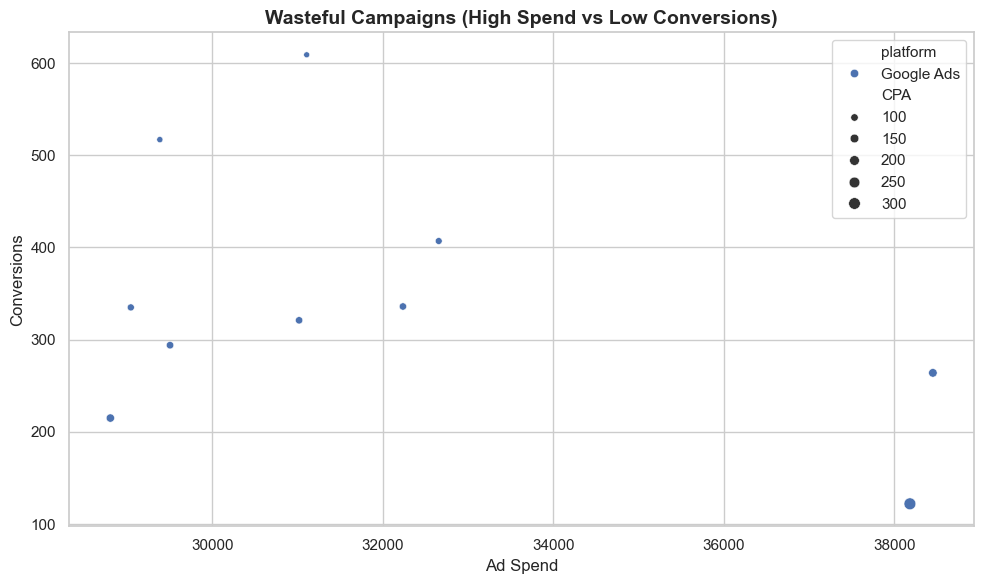

In [57]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=wasteful, x="ad_spend", y="conversions", hue="platform", size="CPA")

plt.title("Wasteful Campaigns (High Spend vs Low Conversions)", fontsize=14, fontweight='bold')
plt.xlabel("Ad Spend")
plt.ylabel("Conversions")

plt.tight_layout()
plt.show()

### Insight:
**The top wasteful campaign spent `$38,453` (Video on Google Ads) and delivered only 264 conversions at a CPA of `$145.66` — more than 3x the dataset average CPA of `$46.61`. A Search campaign spent `$38,184` yielding just 122 conversions at a staggering CPA of `$312.98` — nearly 7x the average. All top 10 wasteful campaigns are on Google Ads, reinforcing the platform's efficiency concerns.**

### Efficient Campaigns (Low CPA)

In [58]:
efficient = df.sort_values(by="CPA").head(10)

efficient[["campaign_type", "platform", "CPA", "conversions"]]

,campaign_type,platform,CPA,conversions
1647,Shopping,TikTok Ads,4.80,306
212,Search,TikTok Ads,4.87,523
81,Video,TikTok Ads,4.95,170
1266,Video,TikTok Ads,4.99,467
957,Search,TikTok Ads,5.01,640
1248,Video,TikTok Ads,5.07,29
1691,Video,TikTok Ads,5.29,263
485,Display,TikTok Ads,5.30,313
1528,Display,TikTok Ads,5.31,206
535,Video,TikTok Ads,5.44,279


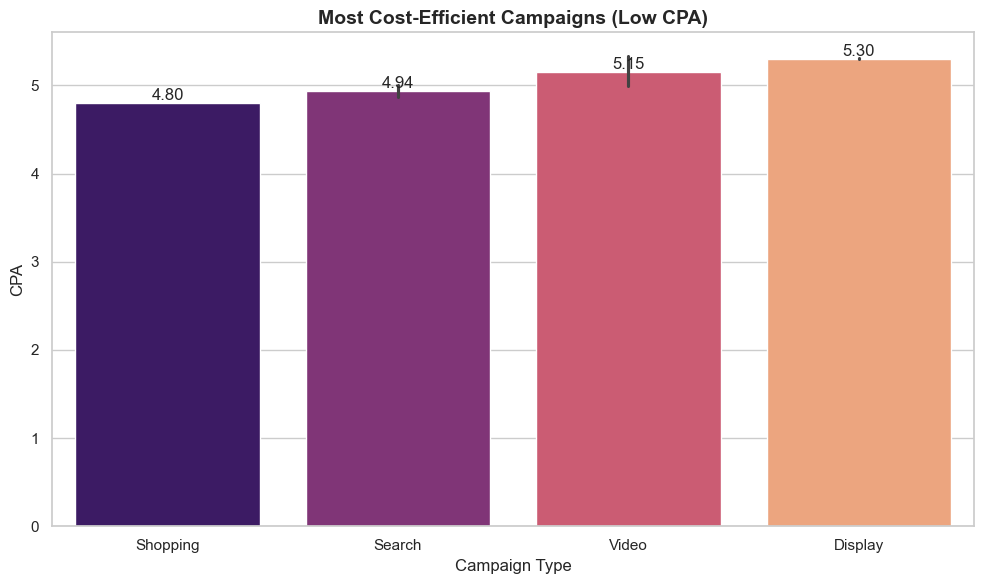

In [60]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=efficient, x="campaign_type", y="CPA", hue="campaign_type", palette="magma")
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
plt.title("Most Cost-Efficient Campaigns (Low CPA)", fontsize=14, fontweight='bold')
plt.xlabel("Campaign Type")
plt.ylabel("CPA")

plt.tight_layout()
plt.show()

### Insight:
**The most efficient campaigns achieve a CPA as low as `$4.80` (Shopping on TikTok Ads), compared to the dataset average of `$46.61` and the worst CPA of `$335.86`. Notably, all 10 of the lowest-CPA campaigns run on TikTok Ads, spanning Shopping, Search, Video, and Display types. These campaigns are the best candidates for immediate budget scaling with minimal acquisition cost risk.**

### Industry Performance

In [61]:
industry_perf = df.groupby("industry").agg({
    "revenue": "sum",
    "ad_spend": "sum"
}).reset_index()

industry_perf["ROAS"] = industry_perf["revenue"] / industry_perf["ad_spend"]

industry_perf.sort_values(by="ROAS", ascending=False)

,industry,revenue,ad_spend,ROAS
4,SaaS,11891991.42,2357561.84,5.044191
1,EdTech,11549934.43,2296978.52,5.028316
0,E-commerce,9637279.69,1923987.08,5.009015
3,Healthcare,10930814.04,2258683.92,4.839462
2,Fintech,10173311.23,2271537.73,4.478601


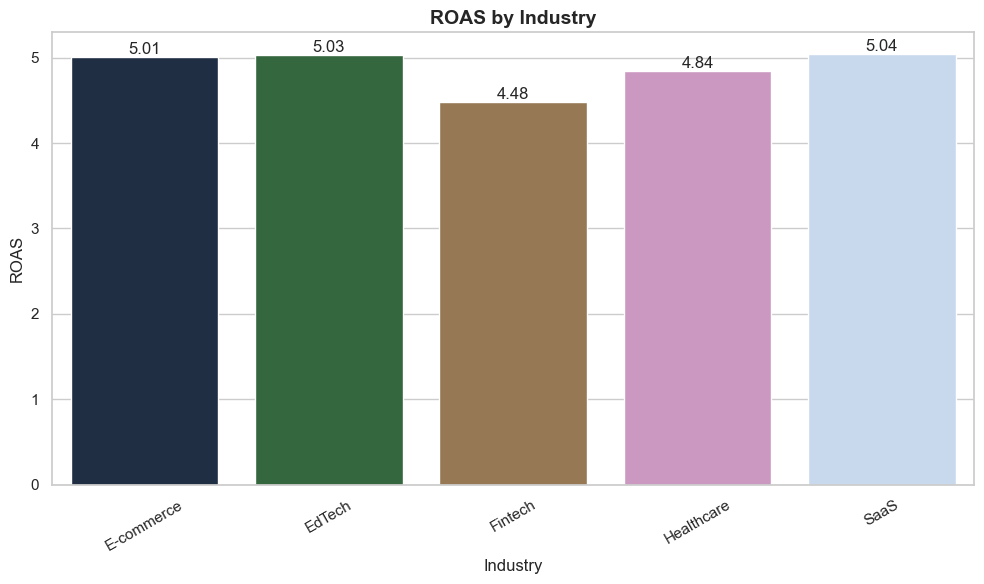

In [63]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=industry_perf, x="industry", y="ROAS", hue="industry", palette="cubehelix")
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
plt.title("ROAS by Industry", fontsize=14, fontweight='bold')
plt.xlabel("Industry")
plt.ylabel("ROAS")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight:
**SaaS leads industry performance with a ROAS of 5.04 (`$11.9M` revenue / `$2.36M` spend), closely followed by EdTech at 5.03 and E-commerce at 5.01. Healthcare sits at 4.84 and Fintech lags at 4.48. The 0.56 ROAS gap between SaaS and Fintech suggests Fintech campaigns may have audience targeting or messaging issues that need optimization. SaaS, EdTech, and E-commerce are the strongest industries to invest in.**

## Ads performance Summary

| Graph | Top Performer | Key Number |
|---|---|---|
| ROAS by Platform | TikTok Ads | ROAS 9.54 |
| ROAS by Campaign Type | Search | ROAS 7.00 |
| Revenue Trend | June 28, 2024 | `$493,585` peak |
| ROAS Trend | March 20, 2024 | ROAS 28.77 peak |
| Ad Spend vs Revenue | Overall | `$54.2M` rev / `$11.1M` spend |
| Best Campaign ROAS | Search | ROAS 5.31 |
| Profit by Platform | TikTok Ads | `$17.57M` profit |
| Wasteful Campaigns | Google Ads Search | CPA `$312.98` |
| Lowest CPA Campaigns | TikTok Ads Shopping | CPA `$4.80` |
| ROAS by Industry | SaaS | ROAS 5.04 |

## 📊 Overall Business Insights

### Campaign Period
This analysis covers **364 days** of global ad campaign data (Jan 1, 2024 – Dec 30, 2024)
across **3 platforms**, **4 campaign types**, and **5 industries**.

---

### 🔢 Key Performance Summary

| Metric | Value |
|---|---|
| Total Impressions | 185,254,234 |
| Total Clicks | 7,132,816 |
| Total Conversions | 326,812 |
| Total Ad Spend | `$11,108,749` |
| Total Revenue | `$54,183,331` |
| Total Profit | `$43,074,582` |
| Overall ROAS | 4.88x |
| Overall CTR | 3.85% |
| Average CPA | `$33.99` |
| Average CPC | `$1.56` |

---

### 1. Platform Performance
- **TikTok Ads** is the most efficient platform with an average ROAS of **9.54** and the
  lowest CPA of `$21.67`, despite spending only **`$2.65M`** — generating **`$17.57M` profit**.
- **Google Ads** consumed the largest budget (**`$6.35M` — 57% of total spend**) but delivered
  the lowest ROAS of **4.11** and the highest CPA of **`$48.43`, making it the least efficient platform**.
- **Meta Ads** performed moderately with a ROAS of **5.66** and CPA of `$28.75` on a
  spend of **`$2.1M`**, generating **`$9.82M` profit**.

### 2. Campaign Type Performance
- **Search** campaigns are the strongest performer with a ROAS of **5.31** and the lowest
  CPA of **`$31.64`**, indicating high user intent and strong conversion potential.
- **Shopping** campaigns are the weakest, with the lowest ROAS of **4.58** and a CPA of **`$34.96`**,
  suggesting poor targeting or creative alignment.
- **Display** and **Video** campaigns fall in between with ROAS of **4.84** and **4.77** respectively.

### 3. Industry Performance
- **SaaS** leads with the highest ROAS of **5.04** and a relatively low CPA of **`$33.08`**,
  followed closely by **EdTech** (ROAS 5.03) and **E-commerce** (ROAS 5.01).
- **Fintech** is the weakest industry with a ROAS of **4.48** and a CPA of **`$34.88`**,
  indicating possible audience mismatch or ineffective ad creatives.
- The ROAS gap between SaaS and Fintech is **0.56 points**, which at this revenue scale
  translates to millions in unrealised returns.

### 4. Wasteful Spend
- **229 campaigns** have a CPA above the dataset average, collectively consuming
  **`$2.13M`** — equivalent to **19.2% of total ad spend** generating poor returns.
- The worst campaign (Google Ads Search) recorded a CPA of **`$312.98`** — nearly
  **9x the overall average CPA of `$33.99`**.
- All top 10 highest-CPA campaigns belong to **Google Ads**, reinforcing the platform's
  efficiency concerns.

### 5. Geographic Performance
- **India** leads in ROAS efficiency among top countries at **5.50**, followed by
  **Australia (4.99)**, **UAE (4.92)**, **Germany (4.96)**, and **Canada (4.79)**.
- **UAE** generated the highest revenue of **`$7.94M`**, with **Australia** and **India**
  closely behind at **`$7.92M`** and **`$7.91M`** respectively.

### 6. Revenue Volatility
- Daily revenue ranged from a peak of **`$493,585`** (Jun 28) to a low of just **`$3,174`**
  (Mar 31) — a **155x swing** — indicating highly inconsistent campaign execution.
- Days where ROAS dropped below **1.0** (e.g., Mar 31: ROAS 0.93) resulted in net losses
  on ad spend for that day.

---

## ✅ Recommendations

1. **Rebalance budget toward TikTok Ads** — With a ROAS of 9.54 vs Google's 4.11,
   shifting even 20% of Google's $6.35M budget to TikTok could yield significantly
   higher returns.

2. **Scale Search campaigns** — Search delivers the best CPA ($31.64) and ROAS (5.31).
   Increasing Search budget at the expense of Shopping (ROAS 4.58) is a high-confidence move.

3. **Audit and pause wasteful campaigns** — 229 campaigns with above-average CPA are
   burning $2.13M (19.2% of total spend). Reallocating this to efficient campaigns
   could directly boost overall ROAS.

4. **Prioritise SaaS, EdTech, and E-commerce industries** — These three industries
   consistently deliver ROAS above 5.0. Fintech campaigns should be reviewed for
   creative refresh or audience retargeting.

5. **Investigate revenue volatility** — The 155x gap between best and worst daily
   revenue signals poor campaign scheduling or seasonal misalignment. Implement
   dayparting and budget pacing strategies to reduce dips.

6. **Focus geographic investment on India and Australia** — Both deliver strong ROAS
   (5.50 and 4.99) with high absolute revenue, making them ideal markets for
   increased ad investment.

7. **Set CPA guardrails** — Any campaign exceeding a CPA of $70 (2x the average)
   should be automatically flagged for review or paused to prevent budget bleed.

---

## 📝 Conclusion

This analysis of **364 days** of global advertising data across **185M+ impressions**,
**`$11.1M` in spend**, and **`$54.2M` in revenue** reveals a portfolio generating a healthy
**overall ROAS of 4.88x** and a **total profit of `$43.07M`**.

However, significant inefficiencies exist. **Google Ads**, despite absorbing 57% of the
budget, delivers the lowest ROAS (4.11) and the highest CPA (`$48.43`). In contrast,
**TikTok Ads** generates a 9.54 ROAS at a CPA of just $21.67 — more than **2x more
efficient** per dollar spent. Similarly, **Search campaigns** consistently outperform
Shopping campaigns across all key metrics.

On the industry front, **SaaS and EdTech** show the strongest monetisation potential,
while **Fintech** underperforms and needs strategic attention. Geographically, **India
and UAE** stand out as high-efficiency, high-revenue markets worth prioritising.

By eliminating the **$2.13M in wasteful spend** (19.2% of budget), rebalancing platform
allocation toward TikTok, and scaling high-performing Search campaigns, the business
has a clear opportunity to **significantly improve ROAS and profit margins** in the
next campaign cycle — without increasing the overall budget.